# Customer Churn Prediction
## Deliverable P1: Exploratory Data Analysis & Preprocessing

**Dataset:** Telco Customer Churn (Kaggle)  
https://www.kaggle.com/datasets/blastchar/telco-customer-churn


## 1. Dataset Context

### Problem Description
Telco is a telecommunications company offering a wide range of services, including multiple lines, internet, online security, device protection, technical support, TV streaming, and movies, among others.

In recent years, the company has experienced a growing loss of customers (churn), which represents a direct and significant impact on revenue. To address this, Telco aims to develop a predictive solution that can identify in advance which customers are most likely to leave, enabling the implementation of targeted retention strategies.

### Dataset Source
- **Origin:** Kaggle — Telco Customer Churn
- **Size:** 7,043 customers and 21 columns
- **Each row:** a customer of a telecommunications company

The metadata contains the following:

- **Customers who left in the last month:** this column is called "Churn".
- **Services subscribed by each customer:** phone service, multiple lines, internet, online security, online backup, device protection, tech support, TV streaming, and movie streaming.
- **Customer account information:** tenure, contract type, payment method, paperless billing, monthly charges, and total charges.
- **Customer demographic information:** gender, age range, and whether they have a partner or dependents.

### Analysis Objective
Identify the profile of customers most at risk of churning, by studying the correlation between demographic variables, contracted services, and financial history. Based on these findings, the company can optimize its services and design retention strategies aimed at reducing the churn rate.


## 2. Data Loading & Initial Exploration


In [ ]:
# Import the libraries we'll use throughout the project
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


### 2.2 Load the Dataset

I'm using `kagglehub` to pull the dataset directly from Kaggle, which keeps the notebook reproducible without needing to manually download any files.


In [ ]:
# Option 1: if you have the CSV downloaded locally
# df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")


In [ ]:
# Option 2: load directly from Kaggle using kagglehub
# Install the library with pandas dataset support
!pip install kagglehub[pandas-datasets]

# Specific imports for loading
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Define the CSV file name we want to load
file_name = "WA_Fn-UseC_-Telco-Customer-Churn.csv"

# Load the dataset from Kaggle (blastchar/telco-customer-churn)
# directly into a pandas DataFrame called df.
df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "blastchar/telco-customer-churn",
    file_name
)


Using Colab cache for faster access to the 'telco-customer-churn' dataset.


### 2.3 Dimensions and Data Types


In [ ]:
# Preview the first rows to get an idea of what the data looks like
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
# And the last rows, to confirm there are no unusual values at the end of the file
df.tail()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [ ]:
# Dataset structure: number of rows and columns
print(f'- The dataset contains {df.shape[0]} records with {df.shape[1]} columns.')


- El Dataset contiene 7043 registros con 21 columnas.


In [ ]:
# Data type per column
df.dtypes


,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


### 2.4 Data Types & Initial Quality Check


In [ ]:
# General information: data types and non-null counts
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Two issues stand out immediately:

1. **`TotalCharges`** is stored as `object` — it should be numeric. This likely means there are non-numeric values hiding in there.
2. **`SeniorCitizen`** is encoded as 0/1, while every other binary variable uses `Yes/No`. That inconsistency would cause problems downstream, so I'll fix it.


### 2.5 Descriptive Statistics


In [ ]:
# Numeric variables: mean, std, quartiles
df.describe()


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


A few things catch my eye from the stats:

- **`tenure`**: std of 25 over a mean of 32 — the customer base is all over the place. Brand-new customers and 6-year veterans coexist. There's no "typical" customer.
- **`MonthlyCharges`**: median (70) is higher than the mean (64), which hints at a group pulling the average down — probably basic plan customers.
- **`TotalCharges`**: std is almost equal to the mean. Very skewed distribution — a small group of long-tenured customers is accumulating large totals.


In [ ]:
# Categorical variables: frequency, mode, unique values
df.describe(include=['object'])


,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,3186-AJIEK,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


In [ ]:
# Distribution of the Contract variable in percentages
df['Contract'].value_counts(normalize=True) * 100


,proportion
Contract,
Month-to-month,55.019168
Two year,24.066449
One year,20.914383


More than half the customer base is on a month-to-month plan — the contract type with the least commitment and, as we'll confirm later, the highest churn risk.


In [ ]:
# Absolute and relative frequency of the target variable (Churn)
print("Absolute frequency:")
print(df['Churn'].value_counts())
# We can see that 1869 out of 7043 customers churned

print("\nRelative Frequency (Percentages):")
percentage = df["Churn"].value_counts(normalize=True) * 100
print(round(percentage, 2))

print(f"\nApproximately 26.5% of the 7,043 customers have left the service")


Frecuencia absoluta:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Frecuencia Relativa (Porcentajes):
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64

Podemos visualizar que aprox el 26.5% de 7043 clientes se han retirado del servicio


In [ ]:
# Gender distribution — there is minimal imbalance between male and female customers
df['gender'].value_counts()


,count
gender,
Male,3555
Female,3488


Gender is almost perfectly balanced. I'll keep it in the analysis for now, but I'm not expecting it to be a meaningful predictor.


### 2.6 Summary: What Needs to Be Fixed

Before jumping into the analysis, there are a few things to address in the data:

1. **`customerID`** — unique per row, zero predictive value. Drop it.
2. **`TotalCharges`** — stored as text, has hidden blank spaces. Convert to numeric.
3. **`SeniorCitizen`** — encoded as 0/1 while everything else is `Yes/No`. Standardize it.
4. **`Churn`** — target variable stored as `Yes/No`. Convert to binary (1/0) for modeling.
5. **Column names** — mix of camelCase and no separators. Standardize to `snake_case`.


### 2.7 Check for Null Values


In [ ]:
# Null count per column
df.isnull().sum()


,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
# Search for hidden whitespace values (which pandas does NOT detect as NaN)
(df == ' ').sum()


,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


At first glance, zero nulls — but that's misleading. Pandas only catches actual `NaN` values. Checking for blank spaces manually reveals **11 hidden empties in `TotalCharges`**. Those need to be handled.


### 2.8 Check for Duplicates


In [ ]:
# Duplicate rows
df.duplicated().sum()


np.int64(0)

## 3. Data Preprocessing (Data Wrangling)


### 3.1 Drop `customerID`


In [ ]:
# Check how many unique values customerID has
df['customerID'].nunique()


7043

In [ ]:
# customerID is unique per row and carries no predictive value, so we drop it.
df = df.drop(columns=['customerID'])
df.shape  # check the shape after dropping


(7043, 20)

### 3.2 Convert `TotalCharges` to Numeric


In [ ]:
# Descriptive stats for TotalCharges (still as object)
df['TotalCharges'].describe()


,TotalCharges
count,7043
unique,6531
top,
freq,11


In [ ]:
# Count values disguised as whitespace
len(df[df['TotalCharges'] == " "])


11

In [ ]:
# Convert TotalCharges to numeric. Blank spaces become NaN.
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Verify they were converted to NaN
print(f"Nulls in TotalCharges: {df['TotalCharges'].isnull().sum()}")

# These correspond to customers with tenure=0 (haven't completed their first month),
# so TotalCharges should be 0
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# Confirm the data type
print(df['TotalCharges'].dtype)


Nulos en TotalCharges: 11
float64


In [ ]:
# Verify that customers with tenure = 0
# haven't completed their first month, so TotalCharges should be 0

df[df['tenure'] == 0][['tenure', 'TotalCharges']]


,tenure,TotalCharges
488,0,0.0
753,0,0.0
936,0,0.0
1082,0,0.0
1340,0,0.0
3331,0,0.0
3826,0,0.0
4380,0,0.0
5218,0,0.0
6670,0,0.0


Those 11 blank entries all belong to customers with `tenure = 0` — they hadn't completed their first billing cycle yet. Filling with 0 is the right call here; using the mean would be wrong since no charge has actually been generated.


### 3.3 Convert `SeniorCitizen` to Categorical


In [ ]:
# Convert SeniorCitizen from 0/1 to No/Yes
df['SeniorCitizen'] = np.where(df['SeniorCitizen'] == 1, 'Yes', 'No')
df['SeniorCitizen'].value_counts()


,count
SeniorCitizen,
No,5901
Yes,1142


### 3.4 Convert `Churn` to Binary Numeric


In [ ]:
# Convert Churn (target variable) to binary numeric:
#   "Yes" → 1 (customer left)
#   "No"  → 0 (customer stayed)
df['Churn'] = df['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)
df['Churn'].value_counts()


,count
Churn,
0,5174
1,1869


### 3.5 Standardize Column Names


In [ ]:
# Standardize column names to lowercase with no spaces
df.columns = df.columns.str.lower().str.replace(' ', '_')
print(df.columns.tolist())


['gender', 'seniorcitizen', 'partner', 'dependents', 'tenure', 'phoneservice', 'multiplelines', 'internetservice', 'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport', 'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling', 'paymentmethod', 'monthlycharges', 'totalcharges', 'churn']


In [ ]:
# Rename only the columns whose meaning isn't immediately obvious.

df.rename(columns={
    'tenure'         : 'months_as_customer',
    'monthlycharges' : 'monthly_charges',
    'totalcharges'   : 'total_charges',
}, inplace=True)

print(df.columns.tolist())


['gender', 'seniorcitizen', 'partner', 'dependents', 'months_as_customer', 'phoneservice', 'multiplelines', 'internetservice', 'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport', 'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling', 'paymentmethod', 'monthly_charges', 'total_charges', 'churn']


## 3.6 Feature Engineering


In [ ]:
# 1. Tenure segment: group customers by how long they've been with the company
df['tenure_segment'] = pd.cut(df['months_as_customer'],
                               bins=[0, 12, 36, 72],
                               labels=['New', 'Mid', 'Loyal'],
                               include_lowest=True)
df['tenure_segment'].value_counts()


,count
segmento_antiguedad,
Leal,3001
Nuevo,2186
Medio,1856


I grouped customers into three lifecycle stages based on how long they've been with the company. This makes it much easier to spot churn patterns by phase — new customers behave very differently from long-term ones.


In [ ]:
# 2. Total contracted services: count how many add-on services ("Yes") each customer has
services = ['onlinesecurity', 'onlinebackup', 'deviceprotection',
            'techsupport', 'streamingtv', 'streamingmovies']

df['total_services'] = (df[services] == 'Yes').sum(axis=1)
df['total_services'].value_counts().sort_index()


,count
total_servicios,
0,2219
1,966
2,1033
3,1118
4,852
5,571
6,284


A customer with 5 active services is far more embedded in the ecosystem than one on a basic plan. This variable captures that engagement level as a single number.


In [ ]:
# 3. True monthly average: total charged divided by months as customer.
# Replace 0 with 1 to avoid division by zero (customers with tenure=0).
df['avg_monthly_charges'] = (df['total_charges'] / df['months_as_customer'].replace(0, 1)).round(2)
df['avg_monthly_charges'].describe()


,promedio_mensual_real
count,7043.000000
mean,64.698184
std,30.270690
min,0.000000
25%,35.650000
50%,70.300000
75%,90.170000
max,121.400000


Unlike `monthly_charges` (which reflects the current plan price), this captures what the customer actually paid per month on average across their whole relationship with the company — relevant if they ever switched plans.


In [ ]:
# Final check: dataset structure ready for EDA
print("Final columns:")
print(df.columns.tolist())
print(f"\nShape: {df.shape}")
print(f"\nData types:")
print(df.dtypes)


Columnas finales:
['gender', 'seniorcitizen', 'partner', 'dependents', 'months_as_customer', 'phoneservice', 'multiplelines', 'internetservice', 'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport', 'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling', 'paymentmethod', 'monthly_charges', 'total_charges', 'churn', 'segmento_antiguedad', 'total_servicios', 'promedio_mensual_real']

Dimensiones: (7043, 23)

Tipos de datos:
gender                     object
seniorcitizen              object
partner                    object
dependents                 object
months_as_customer          int64
phoneservice               object
multiplelines              object
internetservice            object
onlinesecurity             object
onlinebackup               object
deviceprotection           object
techsupport                object
streamingtv                object
streamingmovies            object
contract                   object
paperlessbilling           object
payme

## 4. Exploratory Data Analysis (EDA)

Now that the dataset is clean and enriched, we explore its internal structure. The goal of EDA isn't just to "look at charts" — it's to understand **how each variable behaves**, how dispersed it is, whether it has outliers, and most importantly **how it relates to the target variable (`churn`)**.

We split this into two blocks:
- **4.1 Univariate Analysis:** one variable at a time
- **4.2 Multivariate Analysis:** relationships between two or more variables.


In [ ]:
# Global configuration so all EDA charts look consistent
sns.set_style("whitegrid")
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.titleweight'] = 'bold'

# Variable lists we'll reuse throughout the EDA
num_vars = ['months_as_customer', 'monthly_charges', 'total_charges',
            'total_services', 'avg_monthly_charges']

cat_vars = ['gender', 'seniorcitizen', 'partner', 'dependents', 'phoneservice',
            'multiplelines', 'internetservice', 'onlinesecurity', 'onlinebackup',
            'deviceprotection', 'techsupport', 'streamingtv', 'streamingmovies',
            'contract', 'paperlessbilling', 'paymentmethod', 'tenure_segment']

print(f"Numeric variables: {len(num_vars)}")
print(f"Categorical variables: {len(cat_vars)}")


Variables numéricas: 5
Variables categóricas: 17


### 4.1 Univariate Analysis


#### 4.1.1 Target Variable Distribution: `churn`


In [ ]:
# Absolute and relative frequency of churn
print("Absolute frequency:")
print(df['churn'].value_counts())
print()

print("\nRelative frequency (%):")
print(df['churn'].value_counts(normalize=True) * 100)
print()

print(f"\nApproximately 26.5% of the 7,043 customers have left the service")
print(round(percentage, 2))


Frecuencia absoluta:
churn
0    5174
1    1869
Name: count, dtype: int64


Frecuencia relativa (%):
churn
0    73.463013
1    26.536987
Name: proportion, dtype: float64


Podemos visualizar que aprox el 26.5% de 7043 clientes se han retirado del servicio
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


/tmp/ipykernel_2507/2464113173.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='churn', data=df, palette='rainbow')


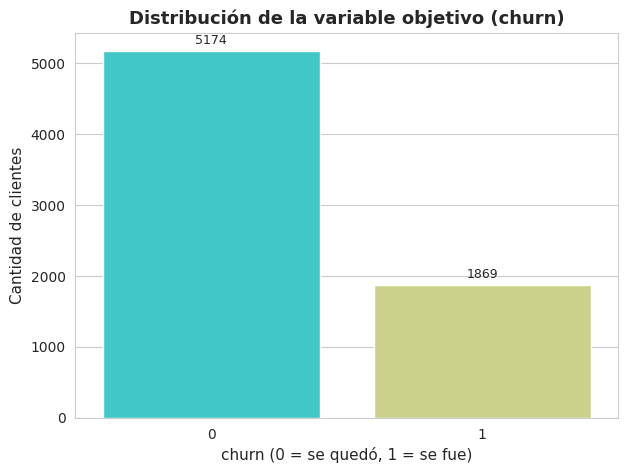

In [ ]:
# Target variable plot
plt.figure(figsize=(7, 5))
sns.countplot(x='churn', data=df, palette='rainbow')
plt.title('Target Variable Distribution (churn)')
plt.xlabel('churn (0 = stayed, 1 = churned)')
plt.ylabel('Number of customers')
ax = plt.gca()
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', padding=3, fontsize=9)
plt.show()


We're losing approximately **26.5%** of customers, meaning **one in four** ends up leaving. This is a moderate class imbalance.

This means that during the modeling phase **we can't rely solely on `accuracy`** — a model that always predicts "stayed" would score ~73% accuracy without learning anything useful. For this reason, in P2 we'll use `F1-score` and `Recall` as our primary metrics, since they properly measure how well the model catches churners.


#### 4.1.2 Descriptive Statistics for Numeric Variables (no charts)


In [ ]:
# Descriptive statistics for numeric variables
df[num_vars].describe()


,months_as_customer,monthly_charges,total_charges,total_servicios,promedio_mensual_real
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304,2.037910,64.698184
std,24.559481,30.090047,2266.794470,1.847682,30.270690
min,0.000000,18.250000,0.000000,0.000000,0.000000
25%,9.000000,35.500000,398.550000,0.000000,35.650000
50%,29.000000,70.350000,1394.550000,2.000000,70.300000
75%,55.000000,89.850000,3786.600000,3.000000,90.170000
max,72.000000,118.750000,8684.800000,6.000000,121.400000


**Interpretation of statistics:**

- **`months_as_customer`** (mean = 32.4, median = 29, std = 25): the dispersion is very high, nearly as large as the mean. This confirms that customers are highly heterogeneous — brand-new customers coexist with six-year veterans. There is no "typical customer."

- **`monthly_charges`** (mean = 64.8, median = 70.4): the median is **higher** than the mean → the distribution is slightly left-skewed (there's a large group of customers paying low amounts, likely basic phone-only plans).

- **`total_charges`** (mean = 2,283, std = 2,266): the standard deviation is nearly equal to the mean → highly asymmetric distribution with a long right tail. This makes sense: a few long-tenured customers accumulate very large totals.

- **`total_services`** (range 0–6, mean = 2): most customers subscribe to few add-on services. The maximum of 6 indicates that some customers take everything on offer.

- **`avg_monthly_charges`** tracks closely with `monthly_charges` but is slightly lower on average, suggesting that longer-tenured customers pay somewhat less per month (likely on older, cheaper plans).


#### 4.1.3 Distribution of Numeric Variables


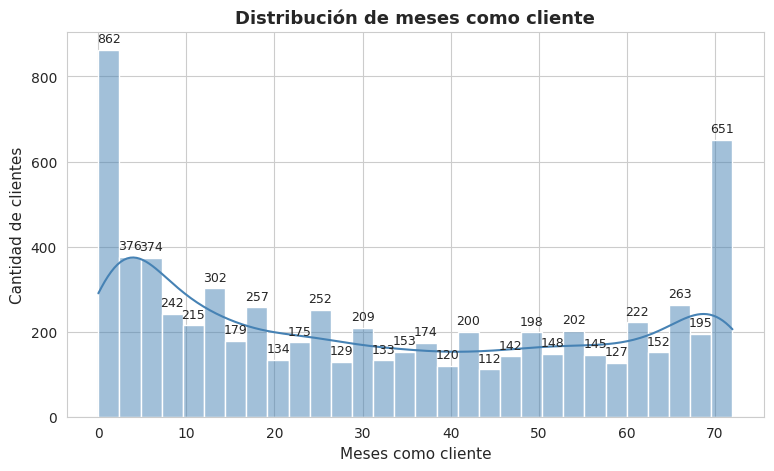

In [ ]:
# Histogram: months_as_customer (customer tenure)
plt.figure(figsize=(9, 5))
sns.histplot(data=df, x='months_as_customer', bins=30, kde=True, color='steelblue')
plt.title('Distribution of Months as Customer')
plt.xlabel('Months as Customer')
plt.ylabel('Number of Customers')
ax = plt.gca()
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', padding=3, fontsize=9)
plt.show()


**`months_as_customer`** shows a bimodal distribution (2 peaks), indicating two dominant subgroups in the data. There's a large spike in the first few months (newly acquired customers) and another near the end (~70 months, long-term customers). This confirms what we saw in the statistics: two very distinct customer profiles — recent arrivals and loyal veterans.


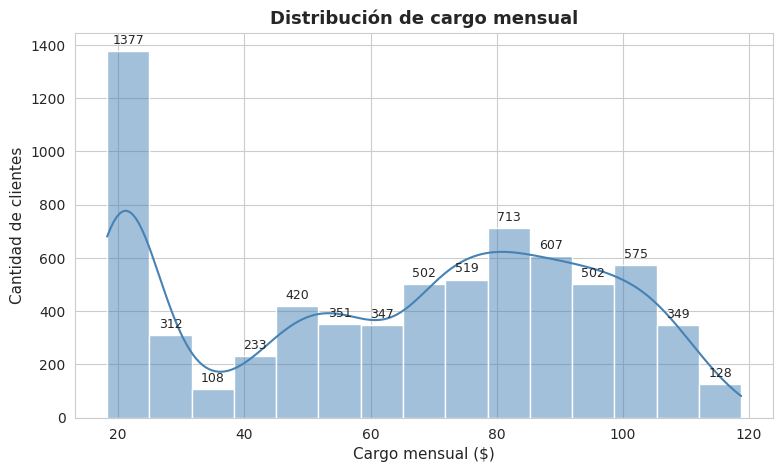

In [ ]:
# Histogram: monthly_charges
plt.figure(figsize=(9, 5))
sns.histplot(data=df, x='monthly_charges', bins=15, kde=True, color='steelblue')
plt.title('Distribution of Monthly Charges')
plt.xlabel('Monthly Charges ($)')
plt.ylabel('Number of Customers')
ax = plt.gca()
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', padding=3, fontsize=9)
plt.show()


**`monthly_charges`** also has 2 peaks. The first is near $20 — likely customers on basic plans (phone only or basic internet). The second appears between $70 and $100, corresponding to full bundles with multiple services. The gap between the two is quite clear, suggesting the company essentially operates with two price segments.


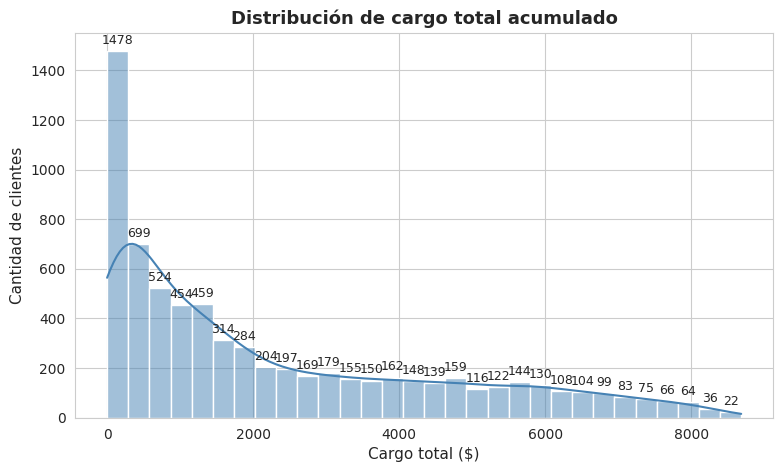

In [ ]:
# Histogram: total_charges (accumulated total)
plt.figure(figsize=(9, 5))
sns.histplot(data=df, x='total_charges', bins=30, kde=True, color='steelblue')
plt.title('Distribution of Total Charges (Accumulated)')
plt.xlabel('Total Charges ($)')
plt.ylabel('Number of Customers')
ax = plt.gca()
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', padding=3, fontsize=9)
plt.show()


**`total_charges`** shows a **strong positive skew** (long right tail). Most customers have accumulated little, while a few long-tenured customers have racked up large totals. This is expected: total charges depend directly on how long the customer has been with the company. In P2, we might consider a **log transformation** if using scale-sensitive models like Logistic Regression or SVM.


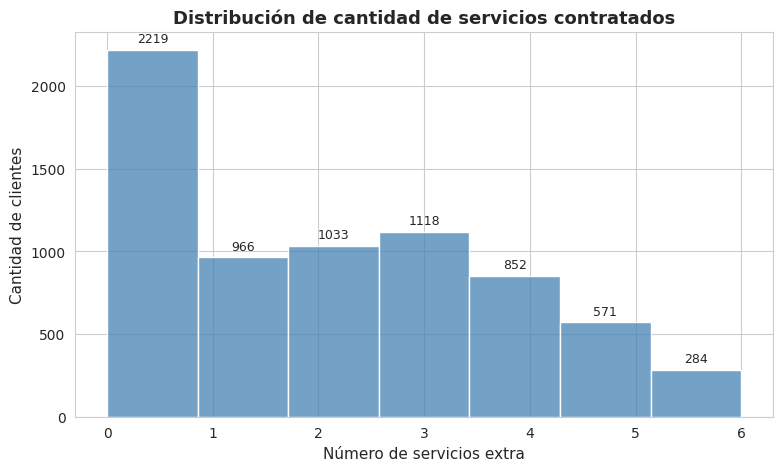

In [ ]:
# Histogram: total_services (number of add-on services)
plt.figure(figsize=(9, 5))
sns.histplot(data=df, x='total_services', bins=7, kde=False, color='steelblue')
plt.title('Distribution of Number of Contracted Services')
plt.xlabel('Number of Add-on Services')
plt.ylabel('Number of Customers')
ax = plt.gca()
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', padding=3, fontsize=9)
plt.show()


**`total_services`** is relatively uniformly distributed between 0 and 6, with some concentration at lower values (0–1). This means most customers subscribe to few add-on services, consistent with the idea of "new customer just trying the basics." Those who reach 4, 5, or 6 services are a minority — but, as we'll see in the multivariate analysis, they are the least likely to churn.


#### 4.1.4 Outlier Check


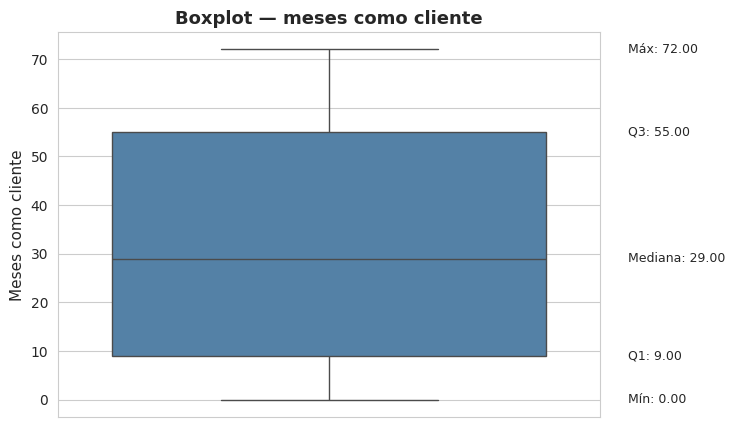

In [ ]:
# Boxplot: months_as_customer
plt.figure(figsize=(7, 5))
sns.boxplot(y='months_as_customer', data=df, color='steelblue')
plt.title('Boxplot — Months as Customer')
plt.ylabel('Months as Customer')
ax = plt.gca()

# Show exact values for each statistic
stats = df['months_as_customer'].describe()
values = {
    'Min':    stats['min'],
    'Q1':     stats['25%'],
    'Median': stats['50%'],
    'Q3':     stats['75%'],
    'Max':    stats['max']
}

for label, val in values.items():
    ax.text(0.55, val, f'{label}: {val:.2f}',
            va='center', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))
plt.show()


**`months_as_customer`** has no outliers (the upper whisker reaches the natural maximum of 72 months). The box extends roughly from 9 to 55 months, confirming the **high natural dispersion** we saw earlier. There's nothing to clean here — this is just the reality of the business.


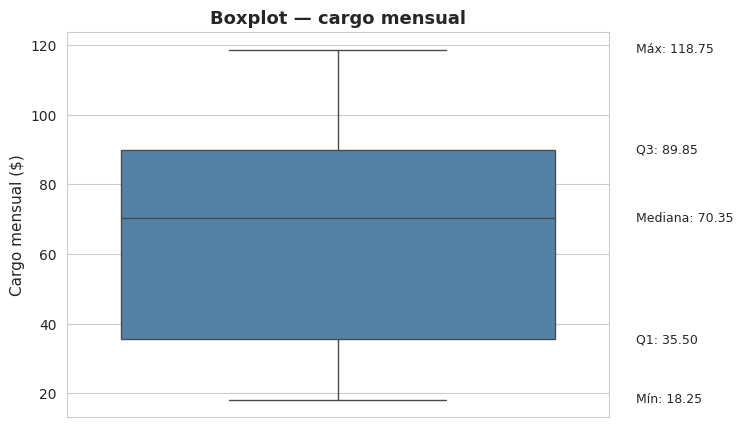

In [ ]:
# Boxplot: monthly_charges
plt.figure(figsize=(7, 5))
sns.boxplot(y='monthly_charges', data=df, color='steelblue')
plt.title('Boxplot — Monthly Charges')
plt.ylabel('Monthly Charges ($)')
ax = plt.gca()

# Show exact values for each statistic
stats = df['monthly_charges'].describe()
values = {
    'Min':    stats['min'],
    'Q1':     stats['25%'],
    'Median': stats['50%'],
    'Q3':     stats['75%'],
    'Max':    stats['max']
}

for label, val in values.items():
    ax.text(0.55, val, f'{label}: {val:.2f}',
            va='center', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))
plt.show()


**`monthly_charges`** also shows no outliers. The box indicates most customers pay between $35 and $90 per month. The distribution is fairly symmetric within the box, though we know from the histogram that it has two distinct peaks.


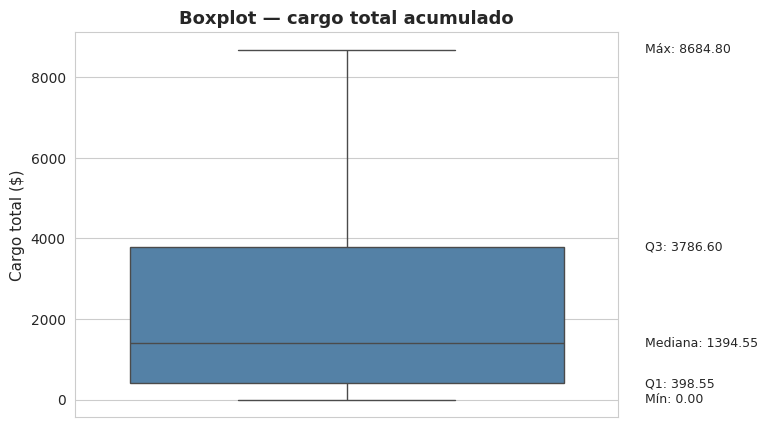

In [ ]:
# Boxplot: total_charges
plt.figure(figsize=(7, 5))
sns.boxplot(y='total_charges', data=df, color='steelblue')
plt.title('Boxplot — Total Charges (Accumulated)')
plt.ylabel('Total Charges ($)')
ax = plt.gca()

# Show exact values for each statistic
stats = df['total_charges'].describe()
values = {
    'Min':    stats['min'],
    'Q1':     stats['25%'],
    'Median': stats['50%'],
    'Q3':     stats['75%'],
    'Max':    stats['max']
}

for label, val in values.items():
    ax.text(0.55, val, f'{label}: {val:.2f}',
            va='center', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))
plt.show()


**`total_charges`** shows a box compressed near 0 with a long upper whisker, confirming the right skew from the histogram. Points above the whisker exist, **but we don't remove them**: they are legitimate long-tenured customers representing the most valuable segment in the dataset. Treating them as outliers would be a costly mistake.


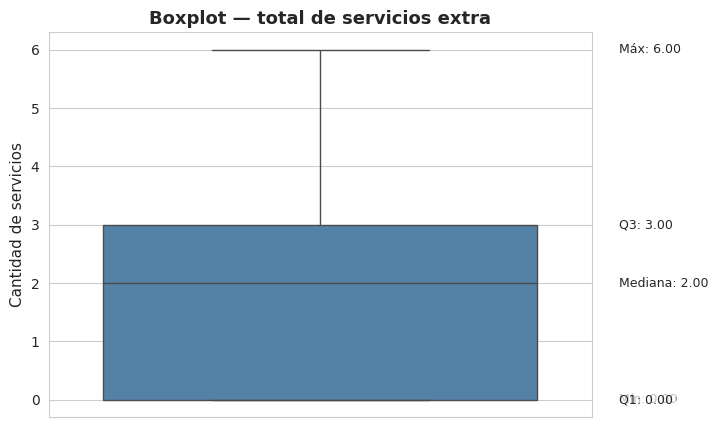

In [ ]:
# Boxplot: total_services
plt.figure(figsize=(7, 5))
sns.boxplot(y='total_services', data=df, color='steelblue')
plt.title('Boxplot — Total Add-on Services')
plt.ylabel('Number of Services')
ax = plt.gca()

# Show exact values for each statistic
stats = df['total_services'].describe()
values = {
    'Min':    stats['min'],
    'Q1':     stats['25%'],
    'Median': stats['50%'],
    'Q3':     stats['75%'],
    'Max':    stats['max']
}

for label, val in values.items():
    ax.text(0.55, val, f'{label}: {val:.2f}',
            va='center', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))
plt.show()


**`total_services`** has no outliers (the range is 0 to 6 and all values are expected). The median is around 2 services, matching the profile of the average customer.


#### 4.1.5 Categorical Variables — Composition


/tmp/ipykernel_2507/1810029286.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='contract', data=df, palette='viridis')


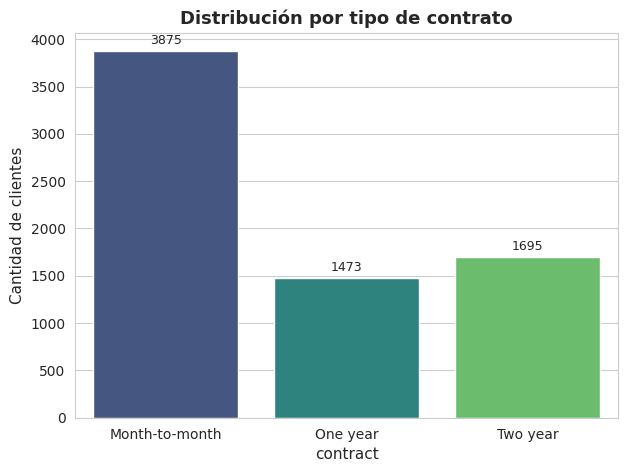

In [ ]:
# Countplot: contract type
plt.figure(figsize=(7, 5))
sns.countplot(x='contract', data=df, palette='viridis')
plt.title('Distribution by Contract Type')
plt.ylabel('Number of Customers')
ax = plt.gca()
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', padding=3, fontsize=9)
plt.show()


**`contract`** is clearly imbalanced: the **month-to-month** contract dominates at ~55%, while one- and two-year contracts are the minority. This dominant category also happens to carry the highest churn risk, so the model will likely assign it significant weight.


/tmp/ipykernel_2507/3326745170.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='paymentmethod', data=df, palette='viridis')


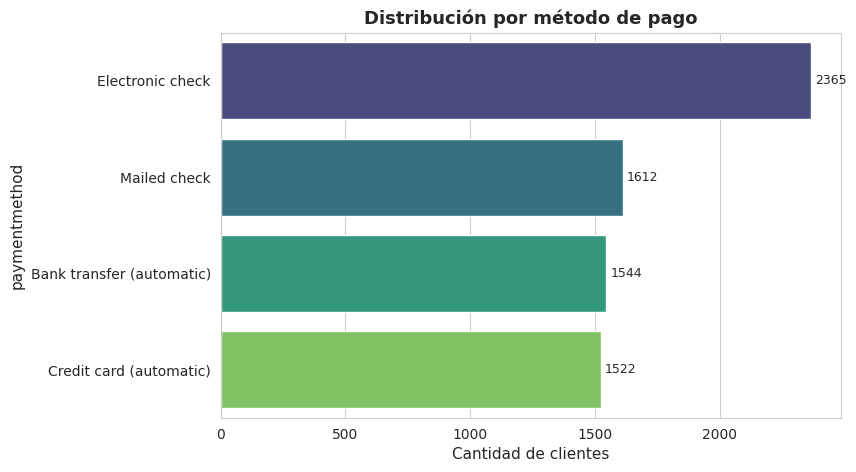

In [ ]:
# Countplot: payment method
plt.figure(figsize=(8, 5))
sns.countplot(y='paymentmethod', data=df, palette='viridis')
plt.title('Distribution by Payment Method')
plt.xlabel('Number of Customers')
ax = plt.gca()
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', padding=3, fontsize=9)
plt.show()


**`paymentmethod`**: Electronic check is the most common payment method. Automatic methods (bank transfer, credit card) are less frequent, which is interesting — manual payment requires a conscious decision each month, while automatic payment creates "exit friction" (the customer would have to actively take steps to cancel).


/tmp/ipykernel_2507/3445426895.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='internetservice', data=df, palette='viridis')


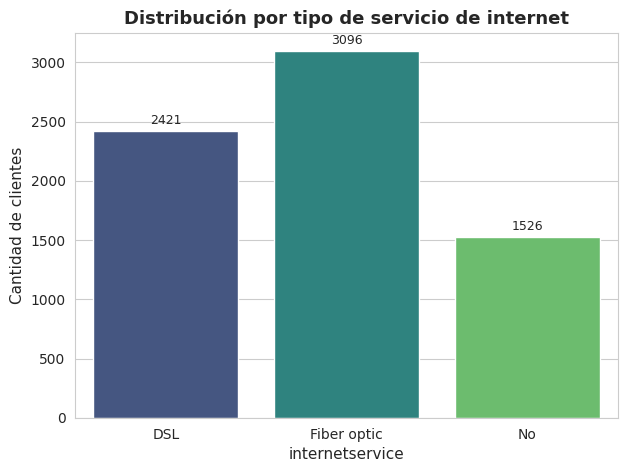

In [ ]:
# Countplot: internet service type
plt.figure(figsize=(7, 5))
sns.countplot(x='internetservice', data=df, palette='viridis')
plt.title('Distribution by Internet Service Type')
plt.ylabel('Number of Customers')
ax = plt.gca()
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', padding=3, fontsize=9)
plt.show()


**`internetservice`**: Fiber optic is the largest segment, followed by DSL. A portion of customers has `No` (they don't use Telco's internet service). As we'll see later, internet service type is strongly associated with churn — especially fiber optic.


/tmp/ipykernel_2507/588576352.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='gender', data=df, palette='viridis')


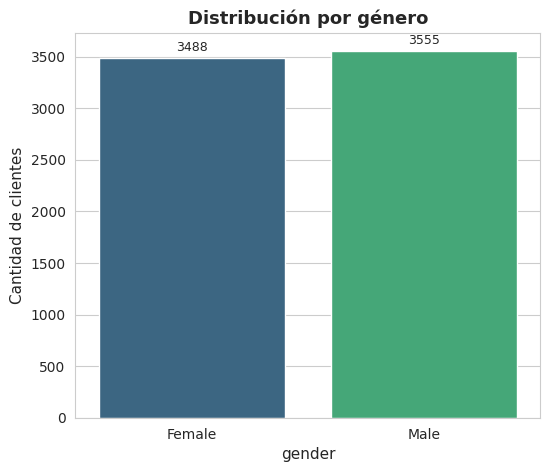

In [ ]:
# Countplot: gender
plt.figure(figsize=(6, 5))
sns.countplot(x='gender', data=df, palette='viridis')
plt.title('Distribution by Gender')
plt.ylabel('Number of Customers')
ax = plt.gca()
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', padding=3, fontsize=9)
plt.show()


**`gender`** is nearly balanced between Female and Male, with only 67 customers difference. This is a healthy sign: no gender dominates and, as we'll see, gender is likely not a relevant predictor for churn.


/tmp/ipykernel_2507/367316705.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='segmento_antiguedad', data=df, palette='viridis',


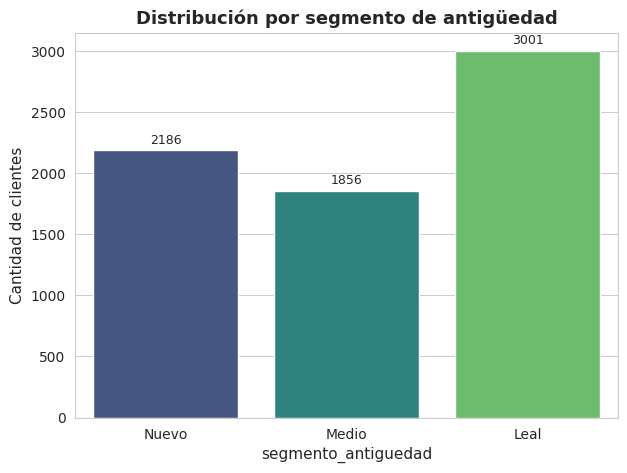

In [ ]:
# Countplot: tenure_segment (engineered feature)
plt.figure(figsize=(7, 5))
sns.countplot(x='tenure_segment', data=df, palette='viridis',
              order=['New', 'Mid', 'Loyal'])
plt.title('Distribution by Tenure Segment')
plt.ylabel('Number of Customers')
ax = plt.gca()
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', padding=3, fontsize=9)
plt.show()


**`tenure_segment`** shows that the `New` (0–12 months) and `Loyal` (37–72 months) segments are the most numerous, with `Mid` (13–36 months) somewhat smaller. This reinforces the bimodal shape of `months_as_customer`: the first 12 months are the critical retention window. If a customer survives that period, there's a good chance they'll become a long-term customer.


In [ ]:
# Frequencies for the main categorical variables
df['contract'].value_counts()


,count
contract,
Month-to-month,3875
Two year,1695
One year,1473


In [ ]:
df['paymentmethod'].value_counts()


,count
paymentmethod,
Electronic check,2365
Mailed check,1612
Bank transfer (automatic),1544
Credit card (automatic),1522


In [ ]:
df['internetservice'].value_counts()


,count
internetservice,
Fiber optic,3096
DSL,2421
No,1526


### 4.2 Multivariate Analysis

We now know how each variable looks in isolation. Next, we explore **how they relate to each other**, especially how each predictor relates to `churn`. This is where the real signals for the model emerge.


#### 4.2.1 Correlations Between Numeric Variables


In [ ]:
# Covariance matrix (numeric variables)
df[num_vars].cov()


,months_as_customer,monthly_charges,total_charges,total_servicios,promedio_mensual_real
months_as_customer,603.168108,183.196987,4.599442e+04,22.428700,185.405308
monthly_charges,183.196987,905.410934,4.441523e+04,40.291356,905.705042
total_charges,45994.421944,44415.233678,5.138357e+06,3119.570156,44699.806605
total_servicios,22.428700,40.291356,3.119570e+03,3.413928,40.257841
promedio_mensual_real,185.405308,905.705042,4.469981e+04,40.257841,916.314675


In [ ]:
# Pearson correlation (measures linear relationships)
df[num_vars].corr()


,months_as_customer,monthly_charges,total_charges,total_servicios,promedio_mensual_real
months_as_customer,1.000000,0.247900,0.826178,0.494263,0.249391
monthly_charges,0.247900,1.000000,0.651174,0.724706,0.994355
total_charges,0.826178,0.651174,1.000000,0.744827,0.651435
total_servicios,0.494263,0.724706,0.744827,1.000000,0.719782
promedio_mensual_real,0.249391,0.994355,0.651435,0.719782,1.000000


In [ ]:
# Spearman correlation (rank-based, captures non-linearities)
df[num_vars].corr(method='spearman')


,months_as_customer,monthly_charges,total_charges,total_servicios,promedio_mensual_real
months_as_customer,1.000000,0.276417,0.889696,0.470536,0.276411
monthly_charges,0.276417,1.000000,0.638028,0.743557,0.990696
total_charges,0.889696,0.638028,1.000000,0.716412,0.638854
total_servicios,0.470536,0.743557,0.716412,1.000000,0.738724
promedio_mensual_real,0.276411,0.990696,0.638854,0.738724,1.000000


**Interpretation:**

- **`months_as_customer` ↔ `total_charges`**: very high correlation (0.83) → **multicollinearity**. Makes sense: the longer the customer has been around, the more they've accumulated.
- **`monthly_charges` ↔ `total_charges`**: moderate correlation (0.65). Expected, but not identical — plans can change over time.
- **`monthly_charges` ↔ `total_services`**: high correlation (0.7) → more contracted services implies a higher monthly charge. This is almost a tautology.

**Decision for P2:** we'll need to decide whether to **drop `total_charges`** (since it's nearly a combination of `months_as_customer` × `monthly_charges`) or apply **regularization** (Lasso/Ridge) to let the model handle it.

Comparing Pearson and Spearman, values are very similar, suggesting relationships are primarily linear with no major hidden non-linearities.


#### 4.2.2 Correlation Heatmap


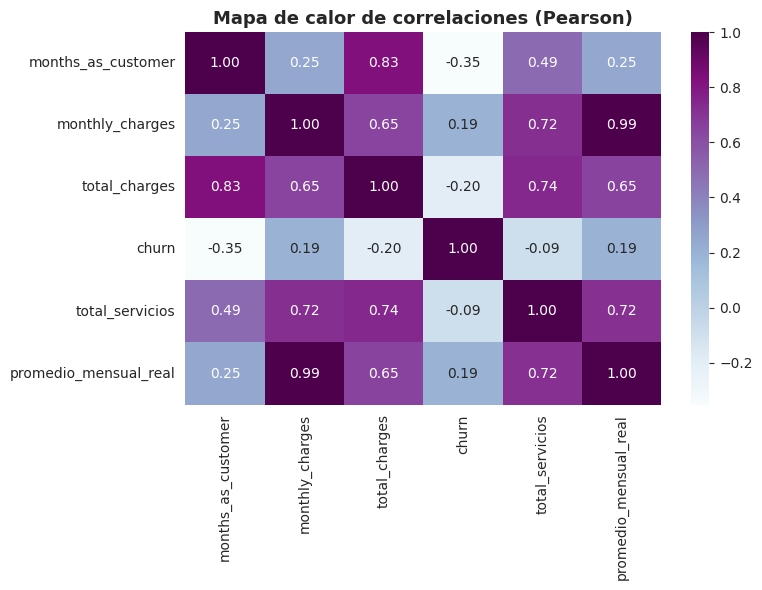

In [ ]:
# Heatmap of correlations for all numeric variables
plt.figure(figsize=(8, 6))
df_numeric = df.select_dtypes(include='number')
sns.heatmap(df_numeric.corr(), annot=True, cmap='BuPu', fmt='.2f')
plt.title('Correlation Heatmap (Pearson)')
plt.tight_layout()
plt.show()


The heatmap visualizes the **multicollinearity** we identified numerically:

- The dark purple block between `months_as_customer` and `total_charges` (0.83) represents the strongest relationship in the dataset.
- `monthly_charges` and `total_services` (~0.7) is the second strongest and equally expected.
- The remaining pairs have low correlations, indicating the variables are reasonably independent.

For the P2 model, **`total_charges` is a candidate for removal** since it adds almost no information that `months_as_customer` and `monthly_charges` don't already provide.


### 4.2.3 Which Numeric Variables Are Most Associated with Churn?


#### 4.2.4 Numeric Variables vs Churn


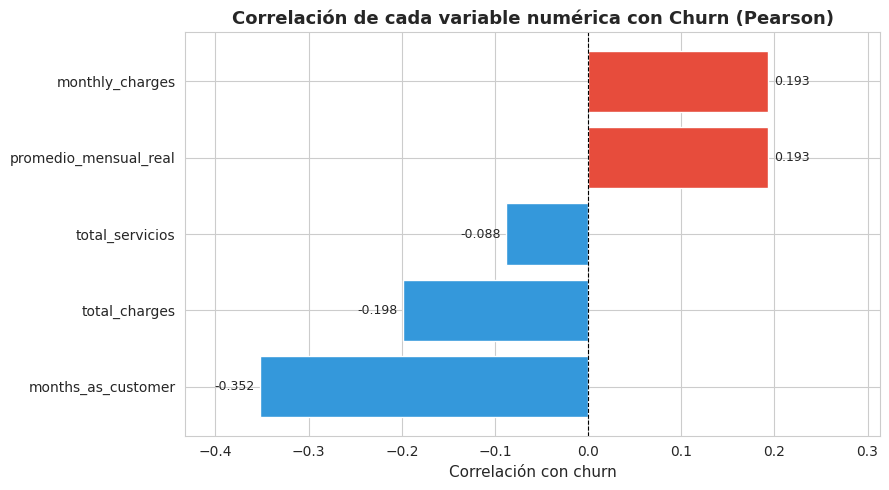

months_as_customer      -0.352229
total_charges           -0.198324
total_servicios         -0.087698
promedio_mensual_real    0.193300
monthly_charges          0.193356


In [ ]:
# Correlation of each numeric variable with churn (sorted)
corr_churn = (
    df.select_dtypes(include='number')
      .corr()['churn']
      .drop('churn')
      .sort_values()
)

# Visualization: horizontal bars colored by sign
plt.figure(figsize=(9, 5))
colors = ['#e74c3c' if v > 0 else '#3498db' for v in corr_churn.values]
bars = plt.barh(corr_churn.index, corr_churn.values, color=colors, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.bar_label(bars, fmt='%.3f', padding=4, fontsize=9)
plt.title('Correlation of Each Numeric Variable with Churn (Pearson)')
plt.xlabel('Correlation with churn')
plt.xlim(corr_churn.min() - 0.08, corr_churn.max() + 0.12)
plt.tight_layout()
plt.show()

# Value table
print(corr_churn.to_string())


/tmp/ipykernel_2507/1449888553.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='churn', y='months_as_customer', data=df, palette='rainbow')


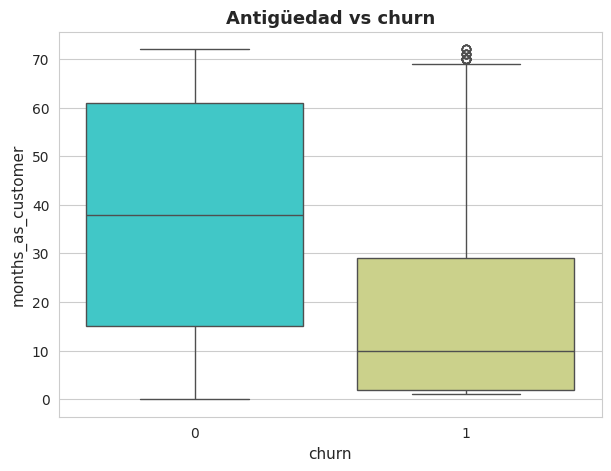

In [ ]:
# Boxplot: months_as_customer vs churn
plt.figure(figsize=(7, 5))
sns.boxplot(x='churn', y='months_as_customer', data=df, palette='rainbow')
plt.title('Customer Tenure vs Churn')
plt.show()


**Interpretation — correlation with `churn`:**

- **`months_as_customer` (strong negative, ~-0.35):** longer-tenured customers are *less* likely to churn.
- **`total_charges` (moderate negative, ~-0.20):** since `total_charges` grows with tenure, it also reflects accumulated loyalty.
- **`monthly_charges` (moderate positive, ~0.19):** customers paying more per month tend to churn more. Possible signal of perceived price-quality mismatch.
- **`total_services` (mild negative, ~-0.16):** having more services creates slight retention through "lock-in."
- **`avg_monthly_charges` (mild positive, ~0.13):** similar to `monthly_charges`; supports the hypothesis that high price drives churn.
- **`seniorcitizen` (mild positive, ~0.15):** senior citizens churn slightly more, though the binary nature of this variable causes Pearson to underestimate the true association.

> **Conclusion:** Numeric correlations confirm that **tenure** and **charges** are the central axes of churn. However, for categorical variables like `contract`, Pearson correlation doesn't capture the association well — which is why crosstabs and grouped charts are essential.


**`months_as_customer` vs `churn`**: the difference is **dramatic**. Customers who stayed have a median of ~38 months, while churners have a median of only ~10 months. **Churners are predominantly new customers** — consistent with retention theory: if a customer survives the first year, the probability of churn drops significantly. This is likely the strongest predictor in the dataset.


/tmp/ipykernel_2507/13996468.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='churn', y='monthly_charges', data=df, palette='rainbow')


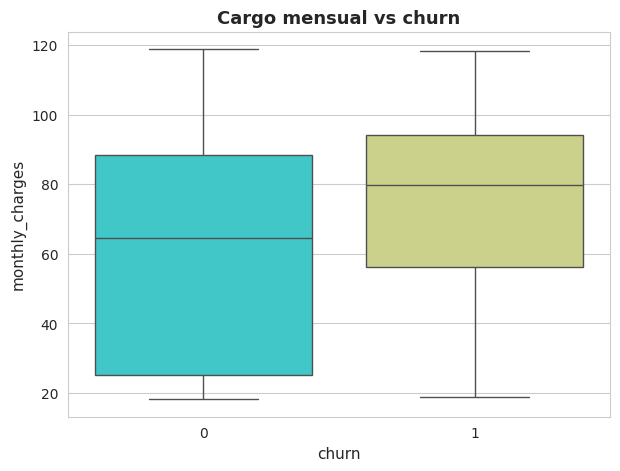

In [ ]:
# Boxplot: monthly_charges vs churn
plt.figure(figsize=(7, 5))
sns.boxplot(x='churn', y='monthly_charges', data=df, palette='rainbow')
plt.title('Monthly Charges vs Churn')
plt.show()


**`monthly_charges` vs `churn`**: customers who left paid **more** (median ~$80) than those who stayed (median ~$65). This suggests that customers with higher charges are more price-sensitive — any inconvenience or cheaper competitor can push them to leave. It may also reflect that premium plans have quality or expectation issues.


/tmp/ipykernel_2507/2586989006.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='churn', y='total_charges', data=df, palette='rainbow')


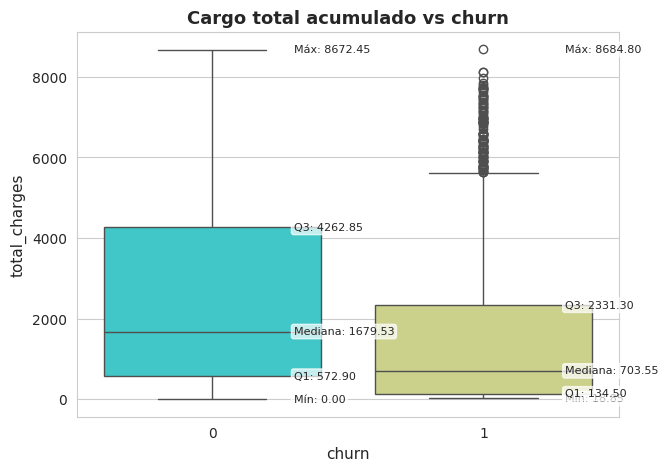

In [ ]:
# Boxplot: total_charges vs churn
plt.figure(figsize=(7, 5))
sns.boxplot(x='churn', y='total_charges', data=df, palette='rainbow')
plt.title('Total Charges vs Churn')
ax = plt.gca()

# Show exact statistic values per group
for i, group in enumerate(df['churn'].unique()):
    stats = df[df['churn'] == group]['total_charges'].describe()
    values = {
        'Min':    stats['min'],
        'Q1':     stats['25%'],
        'Median': stats['50%'],
        'Q3':     stats['75%'],
        'Max':    stats['max']
    }
    for label, val in values.items():
        ax.text(i + 0.3, val, f'{label}: {val:.2f}',
                va='center', fontsize=8,
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))

plt.show()


**`total_charges` vs `churn`**: customers who stayed have accumulated much more — but this **isn't new information**: it simply reflects that those who've been around longer (the non-churners) have accumulated more charges. This variable is highly correlated with `months_as_customer`, making its predictive power largely redundant.


/tmp/ipykernel_2507/2973197531.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='churn', y='total_servicios', data=df, palette='rainbow')


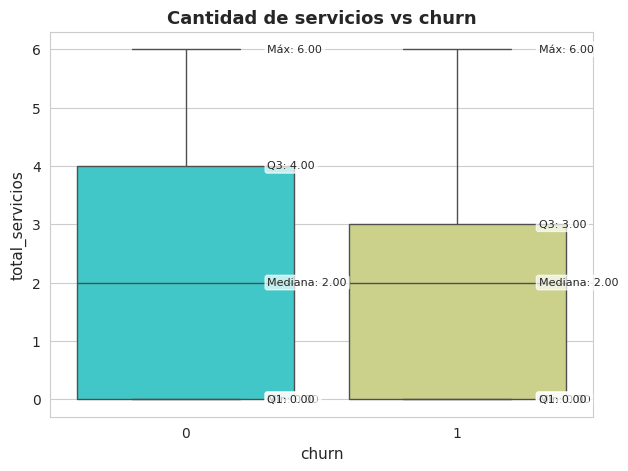

In [ ]:
# Boxplot: total_services vs churn
plt.figure(figsize=(7, 5))
sns.boxplot(x='churn', y='total_services', data=df, palette='rainbow')
plt.title('Number of Services vs Churn')
ax = plt.gca()

# Show exact statistic values per group
for i, group in enumerate(df['churn'].unique()):
    stats = df[df['churn'] == group]['total_services'].describe()
    values = {
        'Min':    stats['min'],
        'Q1':     stats['25%'],
        'Median': stats['50%'],
        'Q3':     stats['75%'],
        'Max':    stats['max']
    }
    for label, val in values.items():
        ax.text(i + 0.3, val, f'{label}: {val:.2f}',
                va='center', fontsize=8,
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))
plt.show()


**`total_services` vs `churn`**: customers who stayed have slightly more services. This confirms the **"more engagement, less churn"** hypothesis — a customer with online security, backup, tech support, and streaming is much more "locked in" than one who only has basic internet.


#### 4.2.5 Categorical Variables vs Churn


In [ ]:
# Crosstab: Contract vs Churn (proportion within each contract type)
pd.crosstab(df['contract'], df['churn'], normalize='index') * 100


churn,0,1
contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


**`contract` vs `churn` — the MOST predictive variable in the dataset:**

- **Month-to-month:** ~43% churn rate
- **One year:** ~11% churn rate
- **Two year:** ~3% churn rate

A month-to-month customer is **14 times more likely** to churn than a two-year contract customer. The business conclusion is crystal clear: **long-term contracts protect customers**, and should be the top retention lever.


In [ ]:
# Crosstab: InternetService vs Churn
pd.crosstab(df['internetservice'], df['churn'], normalize='index') * 100


churn,0,1
internetservice,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


**`internetservice` vs `churn`:**

- **Fiber optic:** ~42% churn rate
- **DSL:** ~19%
- **No internet:** ~7%

**Hypothesis:** fiber optic, being the premium service, attracts more demanding customers who actively compare prices and quality. It may also reflect real quality or pricing issues with the fiber offering — worth investigating from an operations standpoint.


In [ ]:
# Crosstab: PaymentMethod vs Churn
pd.crosstab(df['paymentmethod'], df['churn'], normalize='index') * 100


churn,0,1
paymentmethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


**`paymentmethod` vs `churn`**: the **Electronic check** method triples the churn rate compared to automatic methods (bank transfer, credit card). A reasonable explanation: automatic payments create **"exit friction"** — the customer would need to actively cancel, while with electronic check they can simply stop paying next month.


### Demographic Variables vs Churn


#### SeniorCitizen vs Churn


churn             0     1
seniorcitizen            
No             76.4  23.6
Yes            58.3  41.7


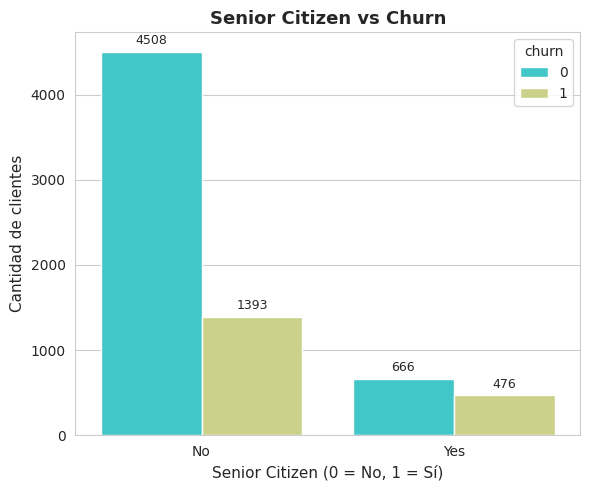

In [ ]:
# Crosstab: SeniorCitizen vs Churn
ct_senior = pd.crosstab(df['seniorcitizen'], df['churn'], normalize='index') * 100
print(ct_senior.round(1))

# Grouped countplot
plt.figure(figsize=(6, 5))
ax = sns.countplot(x='seniorcitizen', data=df, hue='churn', palette='rainbow')
ax.set_title('Senior Citizen vs Churn')
ax.set_xlabel('Senior Citizen (No / Yes)')
ax.set_ylabel('Number of Customers')
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', padding=3, fontsize=9)
plt.tight_layout()
plt.show()


**`seniorcitizen` vs `churn`:** senior customers show a significantly higher churn rate (41%) compared to non-seniors (24%). Although they represent only ~16% of the dataset, they are a high-risk segment that deserves special attention in retention strategies.


churn      0     1
gender            
Female  73.1  26.9
Male    73.8  26.2


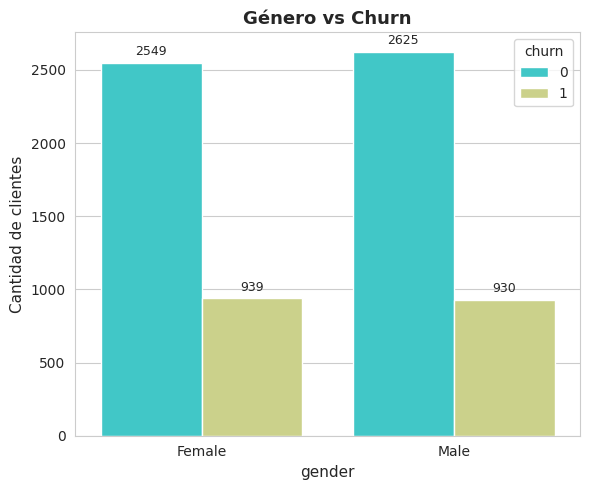

In [ ]:
# Crosstab: Gender vs Churn
ct_gender = pd.crosstab(df['gender'], df['churn'], normalize='index') * 100
print(ct_gender.round(1))

# Grouped countplot
plt.figure(figsize=(6, 5))
ax = sns.countplot(x='gender', data=df, hue='churn', palette='rainbow')
ax.set_title('Gender vs Churn')
ax.set_ylabel('Number of Customers')
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', padding=3, fontsize=9)
plt.tight_layout()
plt.show()


**`gender` vs `churn`:** the churn rate is nearly identical between male and female customers. Gender is **not a predictive variable** for churn in this dataset.


churn       0     1
partner            
No       67.0  33.0
Yes      80.3  19.7


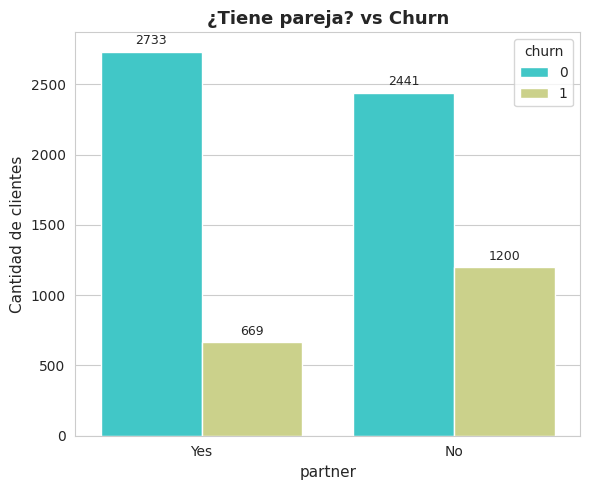

In [ ]:
# Crosstab: Partner vs Churn
ct_partner = pd.crosstab(df['partner'], df['churn'], normalize='index') * 100
print(ct_partner.round(1))

# Grouped countplot
plt.figure(figsize=(6, 5))
ax = sns.countplot(x='partner', data=df, hue='churn', palette='rainbow')
ax.set_title('Has a Partner? vs Churn')
ax.set_ylabel('Number of Customers')
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', padding=3, fontsize=9)
plt.tight_layout()
plt.show()


**`partner` vs `churn`:** customers without a partner churn more (~33%) than those with one (~20%). Having a partner acts as a stabilizing factor.


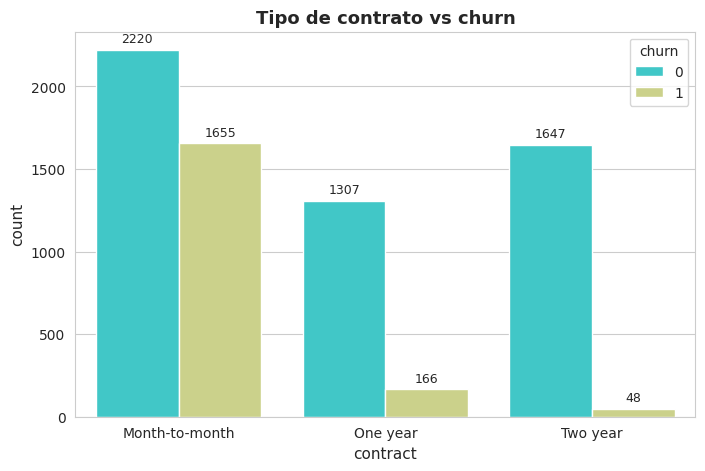

In [ ]:
# Grouped countplot: contract vs churn
plt.figure(figsize=(8, 5))
sns.countplot(x='contract', data=df, hue='churn', palette='rainbow')
plt.title('Contract Type vs Churn')
ax = plt.gca()
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', padding=3, fontsize=9)
plt.show()


`contract` is the strongest visual predictor. The churn rate drops dramatically as the contract length increases.


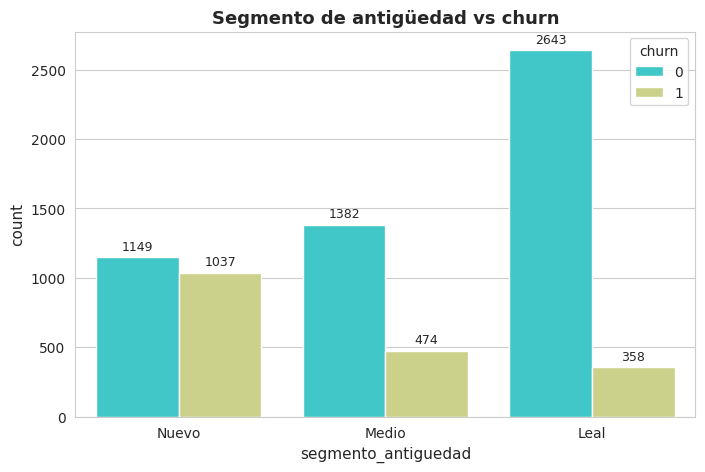

In [ ]:
# Grouped countplot: tenure_segment vs churn
plt.figure(figsize=(8, 5))
sns.countplot(x='tenure_segment', data=df, hue='churn',
              palette='rainbow', order=['New', 'Mid', 'Loyal'])
plt.title('Tenure Segment vs Churn')
ax = plt.gca()
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', padding=3, fontsize=9)
plt.show()


**`tenure_segment`** confirms that new customers (0–12 months) churn the most, while loyal customers (37–72 months) almost never leave.


#### 4.2.7 Scatter Plots


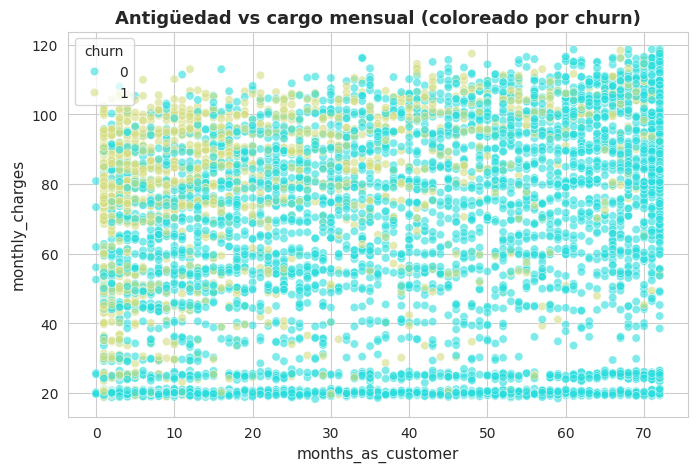

In [ ]:
# Scatterplot 1: months_as_customer vs monthly_charges
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='months_as_customer', y='monthly_charges',
                hue='churn', palette='rainbow', alpha=0.6)
plt.title('Customer Tenure vs Monthly Charges (colored by churn)')
plt.show()


**1. `months_as_customer` vs `monthly_charges`**: churners (class 1) cluster in the **upper-left corner** of the plot — **short tenure + high charges**. This is the profile of a new customer who signs up for an expensive plan and then cancels.


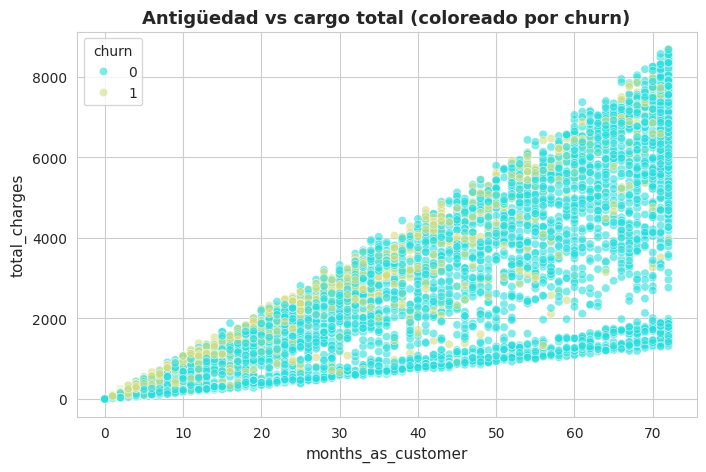

In [ ]:
# Scatterplot 2: months_as_customer vs total_charges
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='months_as_customer', y='total_charges',
                hue='churn', palette='rainbow', alpha=0.6)
plt.title('Customer Tenure vs Total Charges (colored by churn)')
plt.show()


**2. `months_as_customer` vs `total_charges`**: the relationship is nearly linear (consistent with the 0.83 correlation). Churners cluster in the lower-left corner: low tenure and, therefore, low accumulated total. This chart makes the multicollinearity between both variables visually obvious.


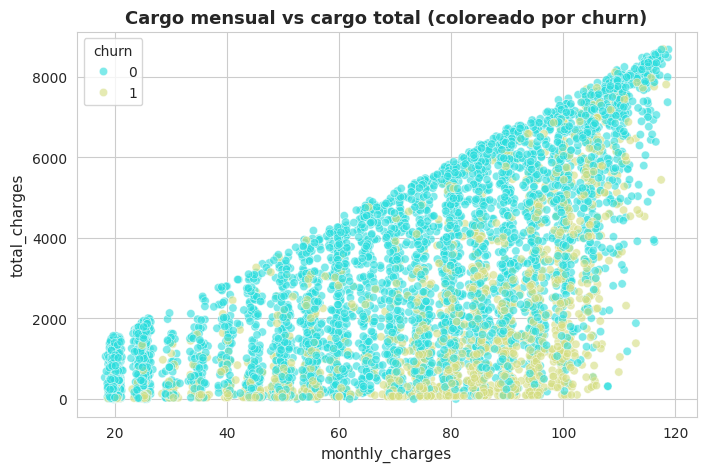

In [ ]:
# Scatterplot 3: monthly_charges vs total_charges
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='monthly_charges', y='total_charges',
                hue='churn', palette='rainbow', alpha=0.6)
plt.title('Monthly Charges vs Total Charges (colored by churn)')
plt.show()


**3. `monthly_charges` vs `total_charges`** shows a **fan shape**: for the same monthly charge, total charges vary widely depending on tenure. Points at the top of the fan are long-tenured customers on expensive plans (the most valuable), while points at the bottom are new customers.


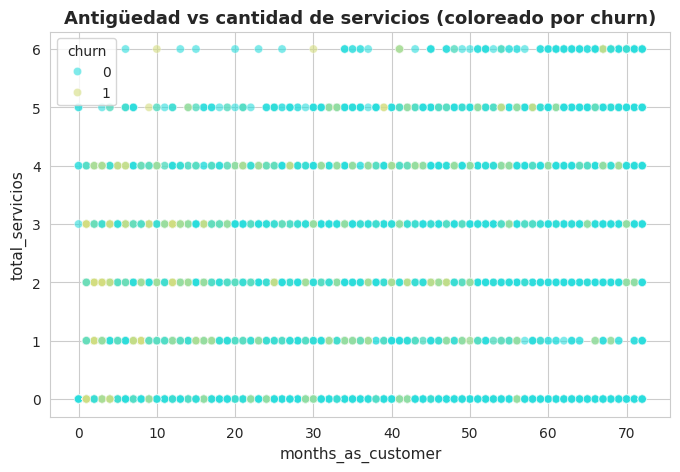

In [ ]:
# Scatterplot 4: months_as_customer vs total_services
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='months_as_customer', y='total_services',
                hue='churn', palette='rainbow', alpha=0.6)
plt.title('Customer Tenure vs Number of Services (colored by churn)')
plt.show()


**4. `months_as_customer` vs `total_services`**: longer-tenured customers tend to have more contracted services. **Engagement grows over time** — as customers become more familiar with the company, they add more services. This explains why the few churners in this chart tend to cluster at the bottom (fewer services).


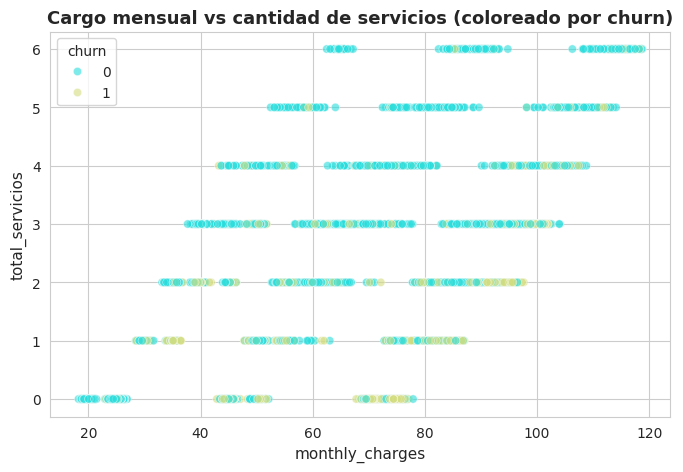

In [ ]:
# Scatterplot 5: monthly_charges vs total_services
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='monthly_charges', y='total_services',
                hue='churn', palette='rainbow', alpha=0.6)
plt.title('Monthly Charges vs Number of Services (colored by churn)')
plt.show()


**5. `monthly_charges` vs `total_services`**: a clear positive linear relationship → **more contracted services = higher monthly charge**. This is expected and essentially explains the 0.7 correlation between the two variables.
Churners appear distributed across the full range of services, so this variable alone doesn't separate the classes well.


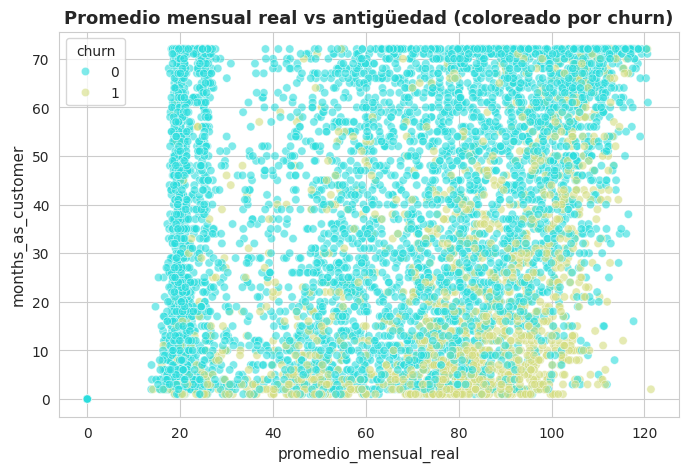

In [ ]:
# Scatterplot 6: avg_monthly_charges vs months_as_customer
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='avg_monthly_charges', y='months_as_customer',
                hue='churn', palette='rainbow', alpha=0.6)
plt.title('Average Monthly Charges vs Customer Tenure (colored by churn)')
plt.show()


**6. `avg_monthly_charges` vs `months_as_customer`**: new customers pay similar average charges to long-tenured ones → there don't appear to be **loyalty discounts**. Churn once again concentrates in the low-tenure band, regardless of average payment.


## 5. General EDA Conclusions

The dataset has a churn rate of approximately 26.5% — a moderate imbalance that requires careful metric selection. In P2, we'll prioritize **F1-score** and **Recall** over accuracy to properly evaluate model performance on the minority class.

The clearest finding is that **contract type almost entirely determines churn behavior**: a month-to-month customer is 14 times more likely to churn than a two-year contract customer. Compounding this, the first year is the critical retention window — churners have a median tenure of only ~10 months. Fiber optic service and electronic check payment also concentrate high churn rates, pointing to value perception issues in those segments.

On variable relationships, there is significant multicollinearity between `months_as_customer` and `total_charges` (~0.83), so `total_charges` will be dropped in P2 to avoid redundancy in the model.

The variables with the highest expected predictive power are `contract`, `months_as_customer`, `internetservice`, and `paymentmethod`. Individual service columns can be consolidated into `total_services` without losing relevant information.
